## Setup

This notebook walks through `pydantic-ai`'s capability layers:

- Function tools — plain, with `RunContext` deps, with retries, and with dynamic registration.
- Provider capabilities — `WebSearch`, `WebFetch`, `Thinking`.
- Builtin tools — `WebSearchTool`, `CodeExecutionTool`, `MemoryTool`.
- MCP toolsets.
- BM25 retrieval as a function tool.
- Multimodal input — `BinaryContent`, `ImageUrl`, `DocumentUrl`.

In [17]:
from pathlib import Path
from typing import Literal

from pydantic import Field
from pydantic_ai.models.anthropic import AnthropicModel
from pydantic_ai.providers.anthropic import AnthropicProvider
from pydantic_settings import BaseSettings, SettingsConfigDict
from rich import print as rprint
from rich.markdown import Markdown

PROJECT_ROOT_PATH = Path.cwd().parent.parent


class Settings(BaseSettings):
    model_config = SettingsConfigDict(
        env_file=PROJECT_ROOT_PATH / ".env",
        env_file_encoding="utf-8",
        extra="ignore",
    )

    anthropic_api_key: str = Field(
        ...,
        description="Workshop-allocated Anthropic API key. Required.",
    )
    model_id: str = Field(
        default="claude-haiku-4-5-20251001",
        description="Default model id. Haiku is cheap and fast for the demos.",
    )
    log_level: Literal["DEBUG", "INFO", "WARNING", "ERROR"] = "INFO"


settings = Settings()  # type: ignore[call-arg]

model = AnthropicModel(
    settings.model_id,
    provider=AnthropicProvider(api_key=settings.anthropic_api_key),
)

rprint(Markdown("# Capabilities"))
rprint("model_id  :", settings.model_id)

Capabilities

model_id  : claude-haiku-4-5-20251001

## Function tools — `@agent.tool_plain`

A tool is a Python function the LLM can call. `pydantic-ai` reads the function's signature and docstring, generates the JSON schema the model sees, parses each call, and feeds the return value back into the conversation.

`@agent.tool_plain` is the simplest registration form: the function takes only the tool's own arguments but has no access to `RunContext`. Use it when the tool is self-sufficient and doesn't need per-run state.

Two equivalent ways to register the same function:

- **Constructor**: pass `tools=[lookup_price]` to `Agent(...)`.
- **Decorator**: `@agent.tool_plain` on the function after the agent is built.

In [ ]:
from pydantic_ai import Agent

_PRICE_LIST: dict[str, float] = {
    "basic_plan": 9.99,
    "pro_plan": 29.99,
    "enterprise_plan": 99.99,
    "addon_storage": 4.99,
    "addon_priority_support": 19.99,
}


def lookup_price(item_name: str) -> dict:
    """Look up a product price by canonical name. Returns USD amount or an error."""
    key = item_name.strip().lower()
    if key not in _PRICE_LIST:
        return {"error": "unknown item", "known": sorted(_PRICE_LIST)}
    return {"item_name": key, "price_usd": _PRICE_LIST[key]}


# Style 1: pass via the tools= constructor arg.
agent_via_tools = Agent(
    model,
    tools=[lookup_price],
    instructions="You are a helpful assistant. Use the lookup_price tool for product prices.",
)

# Style 2: build a bare agent, then register the same function as a tool via a decorator.
agent_via_decorator = Agent(model, instructions="You are a helpful assistant.")
agent_via_decorator.tool_plain(lookup_price)

# Both behave identically. Run one to confirm the tool fires.
result = await agent_via_tools.run("What does the pro_plan cost?")
rprint(Markdown(result.output))

The pro_plan costs $29.99 USD.

## Function tools — `@agent.tool` with `RunContext`

When the tool needs access to per-run state (the current user, a database connection, a logger), use `@agent.tool` instead. The function's first argument is a `RunContext[DepsType]` — `pydantic-ai` injects it automatically; the LLM never sees it in the tool schema.

The example below defines a `User` deps model (name + tier) and a tool that applies a tier-based discount on top of `lookup_price` from the previous section.

In [19]:
from pydantic import BaseModel
from pydantic_ai import RunContext


class User(BaseModel):
    name: str
    tier: Literal["basic", "pro"]


discount_agent = Agent[User, str](
    model,
    deps_type=User,
    instructions=(
        "You are a helpful assistant. When asked about a price, call "
        "apply_user_discount so the answer reflects the current user's tier."
    ),
)


@discount_agent.tool
def apply_user_discount(ctx: RunContext[User], item_name: str) -> dict:
    """Apply the current user's tier discount to a catalogue item."""
    item = lookup_price(item_name)
    if "error" in item:
        return item
    discount = 0.20 if ctx.deps.tier == "pro" else 0.0
    discounted = item["price_usd"] * (1 - discount)
    return {
        "item_name": item["item_name"],
        "user": ctx.deps.name,
        "tier": ctx.deps.tier,
        "price_usd": item["price_usd"],
        "discount": discount,
        "price_usd_after_discount": round(discounted, 2),
    }


for u in (User(name="Alice", tier="basic"), User(name="Bob", tier="pro")):
    result = await discount_agent.run("How much does the pro_plan cost for me?", deps=u)
    rprint(f"--- {u.name} ({u.tier}) ---")
    rprint(result.output)
    rprint()

--- Alice (basic) ---

The **pro_plan** costs **$29.99** for you. 

You're currently on the basic tier, which doesn't include a discount on this item. If you upgrade to a higher tier,
you may be eligible for discounts on plans like this one.

--- Bob (pro) ---

The **pro_plan** costs **$23.99/month** for you!

Since you're on the **pro tier**, you receive a **20% discount** on this plan. The regular price is $29.99, but 
with your tier discount applied, you pay $23.99.

## `Tool(fn)` and `ModelRetry`

For finer control, wrap a function in `Tool(fn, ...)` before passing it to `Agent(tools=[...])`. The wrapper exposes per-tool configuration knobs — most importantly `max_retries=`.

Inside a tool, raising `ModelRetry("...")` instead of returning a value tells `pydantic-ai`: *"the model gave me bad input, please feed the error back and ask the model to retry."* Combined with `max_retries=N`, you get a bounded validation loop.

The example below registers a tiny `validate_email` tool that raises `ModelRetry` on malformed addresses. The prompt deliberately gives the model a malformed address so the retry visibly fires.

In [20]:
import re

from pydantic_ai import ModelRetry, Tool

_EMAIL_RE = re.compile(r"^[^@\s]+@[^@\s]+\.[^@\s]+$")


def validate_email(email: str) -> dict:
    """Validate that the argument is a syntactically valid email address."""
    if not _EMAIL_RE.match(email):
        raise ModelRetry(
            f"{email!r} is not a valid email address. "
            "Retry with a proper one (e.g. user@example.com)."
        )
    return {"email": email, "ok": True}


validator_agent = Agent(
    model,
    tools=[Tool(validate_email, max_retries=0)],
    instructions=(
        "You validate email addresses. When the user gives you an address, "
        "call the validate_email tool. If it raises, fix the address and try again."
        "Send the user email as is. Do not try to convert or correct it."
    ),
)

# Force a bad input so the retry visibly fires.
try:
    result = await validator_agent.run(
        "Please validate the email 'alice at example dot com'."
        # "Please validate the email 'alice@example.com'." # this would succeed
    )
    rprint(result.output)
except Exception as e:
    rprint(f"Validation failed after retries: {e}")

Validation failed after retries: Tool 'validate_email' exceeded max retries count of 0

## `prepare=` — dynamic tool registration

`prepare=` is a per-tool async callback that runs at the start of every model call. It receives the `RunContext` and the tool's `ToolDefinition`, and returns either:

- The `ToolDefinition` (possibly modified) — the tool is offered to the model this turn.
- `None` — the tool is hidden from the model this turn.

This lets you gate tools by user tier, feature flag, role, or any other per-run state, without rebuilding the agent.

In the example below, `priority_support_channel` is visible to pro-tier users only.

In [21]:
from pydantic_ai.tools import ToolDefinition


def priority_support_channel() -> str:
    """Return the priority support phone number (pro users only)."""
    return "+1-555-PRO-LINE — answered 24/7 by a human."


async def pro_only(
    ctx: RunContext[User], tool_def: ToolDefinition
) -> ToolDefinition | None:
    return tool_def if ctx.deps.tier == "pro" else None


gated_agent = Agent[User, str](
    model,
    deps_type=User,
    tools=[Tool(priority_support_channel, prepare=pro_only)],
    instructions=(
        "You are a customer support assistant. Use tools when they are available; "
        "otherwise answer from general knowledge of typical support channels."
    ),
)

for u in (User(name="Alice", tier="basic"), User(name="Bob", tier="pro")):
    result = await gated_agent.run("How can I reach support?", deps=u)
    rprint(f"--- {u.name} ({u.tier}) ---")
    rprint(result.output)
    rprint()

--- Alice (basic) ---

I don't have access to specific support contact tools, but here are the typical ways you can reach customer 
support:

**Common Support Channels:**
- **Website**: Look for a "Contact Us" or "Support" page
- **Email**: Check for a support email address (often support@company.com)
- **Phone**: Many companies have a customer service hotline
- **Live Chat**: Often available on the company's website
- **Social Media**: Try messaging on Facebook, Twitter, or LinkedIn
- **Help Center/FAQ**: Many issues can be resolved with self-service resources
- **Ticketing System**: Some companies have online support portals where you can submit tickets

**To reach support more quickly, have ready:**
- Your account number or order ID
- A clear description of your issue
- Any relevant screenshots or details

Could you let me know which company or service you need support for? That way I can give you more specific guidance
on their support channels.

--- Bob (pro) ---

Here are the support options available:

**Priority Support (Pro Users):**
- **Phone:** +1-555-PRO-LINE (answered 24/7 by a human)

If you're a pro user, this is your dedicated support line available around the clock.

**Other typical support channels** (if you're not a pro user):
- **Email support:** Check your account settings or the help section of the website for the support email
- **Help center:** Browse FAQs and documentation online
- **Chat support:** Many services offer live chat during business hours

Could you let me know if you need help with anything specific, or if you're a pro user looking to use the priority 
phone line?

## Capabilities

```
A capability is a reusable, composable unit of agent behavior. Instead of threading multiple arguments through your Agent constructor — instructions here, model settings there, a toolset somewhere else, a history processor on yet another parameter — you can bundle related behavior into a single capability and pass it via the capabilities parameter.
Capabilities can provide any combination of:
Tools — via toolsets or native tools
Lifecycle hooks — intercept and modify model requests, tool calls, and the overall run
Instructions — static or dynamic instruction additions
Model settings — static or per-step model settings
```

Let's look at some of the capabilities provided by the framework itself:
- `WebSearch()` — gives the model access to web search.
- `WebFetch()` — gives the model the ability to fetch a specific URL.

Both are provider-adaptive: on Anthropic they map to the corresponding builtin tools, on OpenAI to the equivalent native features. You don't have to know which is which — flipping the capability on is enough.

In [29]:
from pydantic_ai.capabilities import WebFetch, WebSearch
from typing import Annotated

class AnswerWithCitation(BaseModel):
    answer: Annotated[str, Field(..., description="The answer to the user's question. Plain text.")]
    citations: Annotated[list[str], Field(..., description="The URLs where the answer was found.")]

web_agent = Agent(
    model,
    capabilities=[WebSearch(), WebFetch()],
    instructions=(
        "You are a research assistant. Use web search when you need current information. "
        "Cite the URL you pulled the answer from."
    ),
    output_type=AnswerWithCitation
)

result = await web_agent.run(
    "What is the latest stable release of Python? Give just the version number and a source. Prefer official sources."
)
rprint(result.output)
for i, citation in enumerate(result.output.citations):
    print(f"Citation {i + 1}: {citation}")

/Users/dan/Things/job/datasentics/projects/kbc_workshop/pydantic_ai_workshop/.venv/lib/python3.12/site-packages/pydantic_ai/capabilities/builtin_or_local.py:74: UserWarning: WebSearch local fallback requires the `duckduckgo` optional group — `pip install "pydantic-ai-slim[duckduckgo]"`. Without it, WebSearch only works with models that support it natively.
  self.local = self._default_local()
/Users/dan/Things/job/datasentics/projects/kbc_workshop/pydantic_ai_workshop/.venv/lib/python3.12/site-packages/pydantic_ai/capabilities/builtin_or_local.py:74: UserWarning: WebFetch local fallback requires the `web-fetch` optional group — `pip install "pydantic-ai-slim[web-fetch]"`. Without it, WebFetch only works with models that support it natively.
  self.local = self._default_local()


AnswerWithCitation(answer='3.14.5', citations=['https://www.python.org/downloads/source/'])

Citation 1: https://www.python.org/downloads/source/


## Thinking and `Thinking()` capability

`Thinking(effort=...)` enables extended internal reasoning before the model produces its final answer. On Anthropic, this maps to extended-thinking mode.

Trade-offs:

- **Pro**: better performance on multi-step problems (math, logic, planning).
- **Con**: higher latency and token cost.

`effort` is a choice: `"low"`, `"medium"`, or `"high"`.

You can also toggle thinking with a fixed budget. It's provider-specific

In [ ]:
from pydantic_ai.capabilities import Thinking
from pydantic_ai.models.anthropic import AnthropicModelSettings

model_settings = AnthropicModelSettings(
    max_tokens=2000,
    # anthropic_thinking={'type': 'enabled', 'budget_tokens': 1024}, # Uncomment and try this
)


thinking_agent = Agent(
    model,
    # capabilities=[Thinking(effort="low")], # Try this separately but change max_tokens in model_settings to some higher value 
    model_settings=model_settings,
    instructions="Show your reasoning step by step.",
)

puzzle = (
    "A subscription costs $29.99/month. Alice signs up on March 15th and cancels "
    "on July 8th. Cancellation takes effect at the end of the current billing period, "
    "so she pays for July in full. How much does she pay across all billed months? "
    "Show your reasoning."
)

result = await thinking_agent.run(puzzle)
rprint(Markdown(result.output))

Traceback (most recent call last):
  File "/Users/dan/Things/job/datasentics/projects/kbc_workshop/pydantic_ai_workshop/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3746, in run_code
    await eval(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/2h/0rn53sk962v5pdjbjs_4mplm0000gn/T/ipykernel_18407/3555636010.py", line 24, in <module>
    result = await thinking_agent.run(puzzle)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dan/Things/job/datasentics/projects/kbc_workshop/pydantic_ai_workshop/.venv/lib/python3.12/site-packages/pydantic_ai/agent/abstract.py", line 412, in run
    node = await agent_run.next(node)  # pyright: ignore[reportArgumentType]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/dan/Things/job/datasentics/projects/kbc_workshop/pydantic_ai_workshop/.venv/lib/python3.12/site-packages/pydantic_ai/run.py", line 384, in next
    return await self._run_node_with_hooks(node, self._advance_graph)
           ^

In [ ]:
for message in result.all_messages():
    rprint(f"{message}")

## Builtin tool — `CodeExecutionTool`

`CodeExecutionTool()` lets the model run Python in a provider-managed sandbox during a run. It's useful for:

- Numerical computation the model would otherwise approximate.
- Multi-step transformations where Python is more reliable than mental arithmetic.
- Quick data summaries or plots.

The model decides when to call the tool and the executed code and its output appear in the message history alongside the final answer.

In [ ]:
from pydantic_ai import CodeExecutionTool

code_agent = Agent(
    model,
    builtin_tools=[CodeExecutionTool()],
    instructions=(
        "You are a helpful assistant. When the user asks for a computation, "
        "use the code execution tool rather than estimating mentally."
    ),
)

result = await code_agent.run(
    "Compute the first 20 Fibonacci numbers and return them as a Python list."
)
rprint(result.output)

Here are the first 20 Fibonacci numbers as a Python list:

```python
[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181]
```

The sequence starts with 0 and 1, and each subsequent number is the sum of the previous two numbers.

In [33]:
for message in result.all_messages():
    rprint(message)

ModelRequest(parts=[UserPromptPart(content='Compute the first 20 Fibonacci numbers and return them as a Python 
list.', timestamp=datetime.datetime(2026, 5, 20, 5, 52, 48, 757185, tzinfo=datetime.timezone.utc))], 
timestamp=datetime.datetime(2026, 5, 20, 5, 52, 48, 757486, tzinfo=datetime.timezone.utc), instructions='You are a 
helpful assistant. When the user asks for a computation, use the code execution tool rather than estimating 
mentally.', run_id='019e43f1-9e72-72a4-92f9-2e70202b0b7d', conversation_id='019e43f1-9e72-72a4-92f9-2e6f479c3e80')

ModelResponse(parts=[BuiltinToolCallPart(tool_name='code_execution', args={'command': "python3 << 'EOF'\n# Compute 
the first 20 Fibonacci numbers\nfibonacci = [0, 1]\nfor i in range(2, 20):\n    fibonacci.append(fibonacci[i-1] + 
fibonacci[i-2])\n\nprint(fibonacci)\nEOF\n"}, tool_call_id='srvtoolu_01NRfh551E8cJ8q9Pz1FPuKF', 
provider_name='anthropic', provider_details={'anthropic_tool_name': 'bash_code_execution'}), 
BuiltinToolReturnPart(tool_name='code_execution', content={'content': [], 'return_code': 0, 'stderr': '', 'stdout':
'[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181]\n', 'type': 
'bash_code_execution_result'}, tool_call_id='srvtoolu_01NRfh551E8cJ8q9Pz1FPuKF', timestamp=datetime.datetime(2026, 
5, 20, 5, 52, 54, 472032, tzinfo=datetime.timezone.utc), provider_name='anthropic', 
provider_details={'anthropic_tool_name': 'bash_code_execution'}), TextPart(content='Here are the first 20 Fibonacci
numbers as a Python list:\n\n```python\n[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 
2584, 4181]\n```\n\nThe sequence starts with 0 and 1, and each subsequent number is the sum of the previous two 
numbers.')], usage=RequestUsage(input_tokens=4775, output_tokens=234, details={'input_tokens': 4775, 
'output_tokens': 234, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0}), 
model_name='claude-haiku-4-5-20251001', timestamp=datetime.datetime(2026, 5, 20, 5, 52, 54, 472152, 
tzinfo=datetime.timezone.utc), provider_name='anthropic', provider_url='https://api.anthropic.com', 
provider_details={'finish_reason': 'end_turn', 'container_id': 'container_011CbDJPsooy1PL8Jcpz9aQn'}, 
provider_response_id='msg_018NoTDeRSSvy929PT3FndK8', finish_reason='stop', 
run_id='019e43f1-9e72-72a4-92f9-2e70202b0b7d', conversation_id='019e43f1-9e72-72a4-92f9-2e6f479c3e80')

## `MemoryTool`

`MemoryTool()` lets the agent persist notes across runs (Anthropic-managed memory). But there's a gotcha: it requires a backing function tool *named* `memory` to be defined on the agent. Without that, `pydantic-ai` raises a `UserError` when the agent runs.

The cell below intentionally builds an agent the wrong way to surface the error. A working setup with the backing storage is covered in a later notebook.

In [23]:
from pydantic_ai import MemoryTool
from pydantic_ai.exceptions import UserError

try:
    broken_agent = Agent(model, builtin_tools=[MemoryTool()])
    await broken_agent.run("Remember that I prefer the pro_plan.")
except UserError as exc:
    rprint("UserError raised as expected:")
    rprint(exc)

UserError raised as expected:

Built-in `MemoryTool` requires a 'memory' tool to be defined.

In [ ]:
from pydantic_ai import Agent, MemoryTool

# Storage. In-memory for the demo; swap for a file/DB to actually persist.
_memory_store: dict[str, str] = {}


def memory(command: str, path: str, file_text: str = "", **kwargs) -> str:
    """Backing storage for the Anthropic MemoryTool builtin.

    Dispatches on `command`: view, create, str_replace, delete.
    """
    if command == "view":
        if path.rstrip("/") in ("/memories", ""):
            files = sorted(_memory_store)
            return "\n".join(files) if files else "(no memories yet)"
        return _memory_store.get(path, f"(not found: {path})")

    if command == "create":
        _memory_store[path] = file_text
        return f"created {path}"

    if command == "str_replace":
        old, new = kwargs.get("old_str", ""), kwargs.get("new_str", "")
        if path not in _memory_store:
            return f"not found: {path}"
        _memory_store[path] = _memory_store[path].replace(old, new)
        return f"updated {path}"

    if command == "delete":
        _memory_store.pop(path, None)
        return f"deleted {path}"

    return f"unsupported command: {command}"


memory_agent = Agent(
    model,
    builtin_tools=[MemoryTool()],
    tools=[memory],   # name must be 'memory' — that's the requirement
    instructions=(
        "You are a helpful assistant with persistent memory. When the user shares "
        "a preference or fact about themselves, store it under /memories/ using "
        "the memory tool. When asked a question, first check /memories/ for "
        "relevant context."
    ),
)


# Turn 1 — model stores something.
r1 = await memory_agent.run("I prefer the pro_plan and I dislike email notifications.")
rprint("--- turn 1 ---")
rprint(Markdown(r1.output))
rprint("store after turn 1:", _memory_store)

# Turn 2 — FRESH run, no message_history. Model reads from /memories/ on its own.
r2 = await memory_agent.run("What plan should I look at, and how should we contact you?")
rprint("\n--- turn 2 (fresh run) ---")
rprint(Markdown(r2.output))
rprint("store after turn 2:", _memory_store)

## MCP toolset — `MCPServerStdio`

[Model Context Protocol](https://modelcontextprotocol.io) is a standard for exposing tools (and other primitives) to LLM agents over a process boundary. `pydantic-ai` integrates MCP servers as *toolsets* — collections of tools whose definitions come from the server at runtime.

The cell below:

1. Writes a tiny MCP server to a tempfile. It exposes one tool: `get_product_info(item_name)`.
2. Launches it as a child process via `MCPServerStdio`, passing `sys.executable` so the child uses the same Python interpreter as this kernel.
3. Inside `async with mcp_server:`, runs an agent that has the toolset attached. The model can call `get_product_info` just like any function tool.

Note: The `MCPServerStdio` does not work on Win platform inside Jupyter notebook due to issue with interprocess communication - use `02_mcp_toolset_win.py`.

In [24]:
import sys
import tempfile
from pathlib import Path

from pydantic_ai.mcp import MCPServerStdio

_MCP_SERVER_SCRIPT = """
from mcp.server.fastmcp import FastMCP

_CATALOGUE = {
    "basic_plan": {"price_usd": 9.99, "users": 1, "storage_gb": 5, "support": "email"},
    "pro_plan": {"price_usd": 29.99, "users": 10, "storage_gb": 100, "support": "priority"},
    "enterprise_plan": {"price_usd": 99.99, "users": "unlimited", "storage_gb": 1000, "support": "dedicated"},
}

mcp = FastMCP("catalogue")

@mcp.tool()
def get_product_info(item_name: str) -> dict:
    \"\"\"Return full product info for a catalogue item, or an error if not found.\"\"\"
    key = item_name.strip().lower()
    if key not in _CATALOGUE:
        return {"error": "unknown item", "known": sorted(_CATALOGUE)}
    return {"item_name": key, **_CATALOGUE[key]}

if __name__ == "__main__":
    mcp.run()
"""

_MCP_SERVER_PATH = Path(tempfile.gettempdir()) / "notebook_capabilities_mcp.py"
_MCP_SERVER_PATH.write_text(_MCP_SERVER_SCRIPT)

mcp_server = MCPServerStdio(sys.executable, args=[str(_MCP_SERVER_PATH)], timeout=15)

mcp_agent = Agent(
    model,
    toolsets=[mcp_server],
    instructions=(
        "You are a helpful assistant. Use the catalogue tools to look up "
        "product details when the user asks about a specific plan."
    ),
)

async with mcp_server:
    result = await mcp_agent.run("What is included in the enterprise_plan?")
    rprint(result.output)

The **Enterprise Plan** includes:

- **Price:** $99.99 (USD)
- **Users:** Unlimited
- **Storage:** 1,000 GB (1 TB)
- **Support:** Dedicated support

This is a comprehensive plan designed for large organizations that need unlimited users, substantial storage 
capacity, and priority support from a dedicated team.

## RAG with BM25

When you have a small corpus of factual documents and want the agent to ground its answers in them, the simplest approach is:

1. Index the corpus with a lexical retriever — `BM25Okapi` from `rank_bm25` is fast and dependency-light.
2. Expose a `search_docs(query)` tool to the agent.
3. Let the model decide when to call it.

For larger or more semantic corpora you'd reach for embeddings + a vector store, but for a few thousand documents, BM25 is often enough.

The next two cells define a `SimpleBM25` wrapper, index five inline policy snippets, and register a `search_docs` tool that an agent uses to ground its answer.

In [25]:
from rank_bm25 import BM25Okapi


def _tokenise(text: str) -> list[str]:
    return [t for t in re.findall(r"\w+", text.lower()) if len(t) > 1]


class SimpleBM25:
    def __init__(self, corpus: dict[str, str]):
        self.doc_ids = list(corpus.keys())
        self.texts = [corpus[did] for did in self.doc_ids]
        self._bm25 = BM25Okapi([_tokenise(t) for t in self.texts])

    def search(self, query: str, k: int = 2) -> list[dict]:
        scores = self._bm25.get_scores(_tokenise(query))
        ranked = sorted(zip(self.doc_ids, self.texts, scores), key=lambda x: -x[2])
        return [
            {"doc_id": did, "text": text, "score": float(round(score, 3))}
            for did, text, score in ranked[:k]
        ]


_CORPUS = {
    "returns": (
        "Our return policy allows returns within 30 days of delivery, no questions asked. "
        "Refunds are issued to the original payment method within 5 business days. "
        "Items must be in their original packaging."
    ),
    "shipping": (
        "Standard shipping takes 3-5 business days within the US and is included on orders over $50. "
        "Express shipping (1-2 business days) costs an additional $12.99. International shipping is "
        "available to most countries with delivery in 7-14 business days."
    ),
    "billing": (
        "Subscriptions are billed monthly on the date you signed up. You can cancel any time from your "
        "account settings; cancellation takes effect at the end of the current billing period."
    ),
    "subscriptions": (
        "We offer three subscription tiers: basic_plan ($9.99/month, 1 user), pro_plan ($29.99/month, "
        "10 users), and enterprise_plan ($99.99/month, unlimited users). Annual billing saves 20%."
    ),
    "support": (
        "Email support is available for all customers. Pro and enterprise customers also have access "
        "to priority phone support, answered 24/7 by a human."
    ),
}

retriever = SimpleBM25(_CORPUS)

# Smoke test the index outside the agent loop.
rprint(retriever.search("how do I cancel my subscription?"))

[
    {
        'doc_id': 'subscriptions',
        'text': 'We offer three subscription tiers: basic_plan ($9.99/month, 1 user), pro_plan ($29.99/month, 10 
users), and enterprise_plan ($99.99/month, unlimited users). Annual billing saves 20%.',
        'score': 1.156
    },
    {
        'doc_id': 'billing',
        'text': 'Subscriptions are billed monthly on the date you signed up. You can cancel any time from your 
account settings; cancellation takes effect at the end of the current billing period.',
        'score': 1.085
    }
]

In [26]:
rag_agent = Agent(
    model,
    instructions=(
        "You are a helpful customer support assistant. When the user asks a policy "
        "question, call search_docs first to find relevant context, then answer based "
        "on the retrieved snippets. Cite the doc_id of every snippet you used."
    ),
)


@rag_agent.tool_plain
async def search_docs(query: str, k: int = 2) -> list[dict]:
    """Search the policy corpus for snippets relevant to the user's query. Returns top-k results."""
    return retriever.search(query, k=k)


result = await rag_agent.run("Can I get a refund on a 20-day-old order?")
rprint(Markdown(result.output))

Great news! Based on our return policy, yes, you can get a refund on a 20-day-old order.                           

According to our policy (doc_id: returns), we allow returns within 30 days of delivery, with no questions asked.   
Since your order is only 20 days old, it's well within this timeframe.                                             

Here are the details:                                                                                              

 • Refund Window: 30 days from delivery                                                                            
 • Refund Timeline: Refunds are issued to your original payment method within 5 business days                      
 • Condition: Items must be in their original packaging                                                            

To proceed with your return, please contact our support team or initiate the return through your account. We'll be 
happy to help!

## Multimodal — `BinaryContent`, `ImageUrl`, `DocumentUrl`

Anthropic models support vision and document understanding. `pydantic-ai` exposes three input shapes for non-text content:

- **`BinaryContent(data=..., media_type=...)`** — raw bytes you have in memory. Useful when you just generated the asset (rendered a chart, decoded a base64 string, downloaded an attachment).
- **`ImageUrl(url=...)`** — a URL the provider will fetch.
- **`DocumentUrl(url=...)`** — a URL pointing at a PDF or other supported document format.

The same agent accepts any of these as part of the user's input list: `await agent.run([prompt, BinaryContent(...)])`.

The next cell generates a small "receipt" PNG inline (no committed assets), then runs three flips of the same agent — one with each input shape.

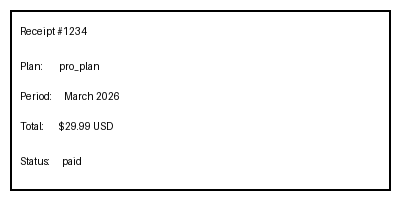

In [27]:
from io import BytesIO

from PIL import Image, ImageDraw
from pydantic_ai import BinaryContent, DocumentUrl, ImageUrl


# Build a tiny "receipt" PNG inline. No assets checked into the repo.
_img = Image.new("RGB", (400, 200), color="white")
_draw = ImageDraw.Draw(_img)
_draw.rectangle([(10, 10), (390, 190)], outline="black", width=2)
_draw.text((20, 25), "Receipt #1234", fill="black")
_draw.text((20, 60), "Plan:        pro_plan", fill="black")
_draw.text((20, 90), "Period:      March 2026", fill="black")
_draw.text((20, 120), "Total:       $29.99 USD", fill="black")
_draw.text((20, 155), "Status:      paid", fill="black")

_buf = BytesIO()
_img.save(_buf, format="PNG")
_receipt_bytes = _buf.getvalue()

display(_img)

In [28]:
vision_agent = Agent(
    model,
    instructions="You are a helpful assistant. Describe what you see, concisely.",
)

# Flip 1: BinaryContent — bytes already in memory.
result = await vision_agent.run([
    "What does this receipt show? Give a one-sentence summary.",
    BinaryContent(data=_receipt_bytes, media_type="image/png"),
])
rprint("--- BinaryContent ---")
rprint(result.output)
rprint()

# Flip 2: ImageUrl — provider fetches a stable public image.
result = await vision_agent.run([
    "Describe this image in one sentence.",
    ImageUrl(url="https://www.gstatic.com/webp/gallery/1.jpg")
])
rprint("--- ImageUrl ---")
rprint(result.output)
rprint()

# Flip 3: DocumentUrl — provider fetches and parses a PDF.
result = await vision_agent.run([
    "Summarise the abstract of this paper in two sentences.",
    # DocumentUrl(url="https://arxiv.org/pdf/1706.03762.pdf"),
    DocumentUrl(url="https://arxiv.org/pdf/2601.16946.pdf")
])
rprint("--- DocumentUrl ---")
rprint(result.output)

--- BinaryContent ---

This receipt shows a paid subscription payment of $29.99 USD for a pro plan covering March 2026.

--- ImageUrl ---

A scenic alpine landscape featuring a deep valley with a winding blue river flowing through forested slopes, 
surrounded by dramatic rocky peaks and mountains under a clear sky.

--- DocumentUrl ---

# Summary

This paper addresses the challenge of using Large Language Models (LLMs) for span labeling tasks—such as named 
entity recognition and error detection—by categorizing existing prompting strategies into three families (tagging, 
indexing, and matching) and introducing LogitMatch, a novel constrained decoding method. LogitMatch forces the 
model's output to align with valid input spans, eliminating span matching issues while maintaining competitive 
performance across diverse tasks, though tagging remains a robust baseline approach.

## Recap

Primitives covered, in roughly the order you'd reach for them:

- **`@agent.tool_plain` / `@agent.tool`** — give the agent a Python function it can call. Use `tool_plain` when the function is self-sufficient; `tool` when it needs deps via `RunContext`.
- **`Tool(fn, max_retries=N)` + `ModelRetry`** — bounded validation loop inside a tool.
- **`prepare=` callbacks** — register or hide tools per run based on `RunContext.deps`.
- **`capabilities=[WebSearch(), WebFetch(), Thinking(...)]`** — high-level switches that map to provider primitives. Same code works across providers.
- **`builtin_tools=[CodeExecutionTool(), MemoryTool()]`** — provider-side tools exposed to the model as named tools. More configurable than capabilities; `MemoryTool` needs a backing `memory` function tool.
- **`toolsets=[MCPServerStdio(...)]`** — tools from an external MCP server started as a child process.
- **BM25 + a `search_docs` tool** — minimal RAG. Reach for embeddings + a vector store when the corpus grows past a few thousand items.
- **`BinaryContent` / `ImageUrl` / `DocumentUrl`** — multimodal input. Use `BinaryContent` for in-memory bytes, the URL forms when the asset is already hosted.

Pick capabilities for simplicity, builtin tools when you need control, and function tools when the capability lives in your own codebase.